# Bài thực hành 1 - Số liệu thống kê
Nhóm 13:
- Vũ Bảo Khôi - 202419071
- Quách Bảo Lâm - 202419075
## 1. Thông tin bộ dữ liệu

Bộ dữ liệu được lấy từ trang web Kaggle, nghiên cứu 4500 học sinh từ trung học tới đại học về ảnh hưởng của các nền tảng mạng xã hội lên cuộc sống của họ.

Bộ dữ liệu thực tế đo 16 danh mục, nhưng trong khuôn khổ bài thực hành nhóm chỉ lấy các danh mục sau để tiến hành phân tính
- Student_ID (String): Mã định danh cho học sinh
- Age(Integer): độ tuổi (nằm trong khoảng từ 16-25 tuổi) - biến định lượng
- Daily_Usage_Hours(Float): thời gian sử dụng mạng xã hội hằng ngày - biến định lượng
- Late_Night_Usage(Booleen): Có sử dụng mạng xã hội qua đêm không - biến định tính
- Weekend_Extra_Hours(Float): Thời gian sử dụng mạng xã hội cuối tuần - biến định lượng

## 2. Xử lí số liệu
### 2.1. Nhập dữ liệu

In [1]:
import pandas as pd

# 1. Đọc dữ liệu
df = pd.read_csv('Social_media_impact_on_life.csv')
columns_to_extract = ['Student_ID', 'Age', 'Daily_Usage_Hours', 'Late_Night_Usage', 'Weekend_Extra_Hours']

# Sử dụng .copy() để tạo một bảng mới hoàn toàn, tránh lỗi cảnh báo của pandas
df_subset = df[columns_to_extract].copy()

# 2. Xử lý các cột định lượng (Ép thành số -> Làm tròn -> Ép thành Int64)
# errors='coerce' sẽ biến các giá trị bị lỗi (như chữ vô tình lẫn vào) thành ô trống (NaN)
df_subset['Age'] = pd.to_numeric(df_subset['Age'], errors='coerce').round().astype('Int64')
df_subset['Daily_Usage_Hours'] = pd.to_numeric(df_subset['Daily_Usage_Hours'], errors='coerce').round().astype('Float64')
df_subset['Weekend_Extra_Hours'] = pd.to_numeric(df_subset['Weekend_Extra_Hours'], errors='coerce').round().astype('Float64')
# 3. Xử lý cột định danh và định tính
df_subset['Student_ID'] = df_subset['Student_ID'].astype('string')
df_subset['Late_Night_Usage'] = df_subset['Late_Night_Usage'].astype('bool')
# 4. Kiểm tra kết quả
print(df_subset.head())

    Student_ID  Age  Daily_Usage_Hours  Late_Night_Usage  Weekend_Extra_Hours
0  STU_2024000   19                8.0              True                  2.0
1  STU_2024001   19                5.0              True                  1.0
2  STU_2024002   17               11.0              True                  2.0
3  STU_2024003   16                6.0              True                  2.0
4  STU_2024004   17                3.0              True                  3.0


### 2.2. Với một biến định lượng, ước lượng kỳ vọng tổng thể bằng khoảng tin cậy 95%.

Xét cột "Daily_Usage_Hours".

Gọi X là biến ngẫu nhiên đại diện cho thời gian sử dụng mạng xã hội hàng ngày của sinh viên.

$\overline{X}$ là biến ngẫu nhiên đại diện cho thời gian trung bình sử dụng mạng xã hội.

Vì $E(\overline{X}) = \mu \Rightarrow \overline{X}$ là ước lượng không chệch cho kỳ vọng tổng thể $\mu$

Vì n đủ lớn ($n=4500>30$), áp dụng định lý giới hạn giá trị trung tâm ta có:

$\overline{X} \sim N(\mu, \dfrac{\sigma ^2}{n})$

Thành lập mẫu ngẫu nhiên $W_X = (X_1, X_2,....,X_{4500})$, cỡ mẫu $n=4500$

Chuẩn hóa: $ Z = \dfrac{\overline{X} - \mu}{\sigma_{\overline{X}}} = \dfrac{\overline{X} - \mu}{\dfrac{\sigma}{\sqrt{n}}}$

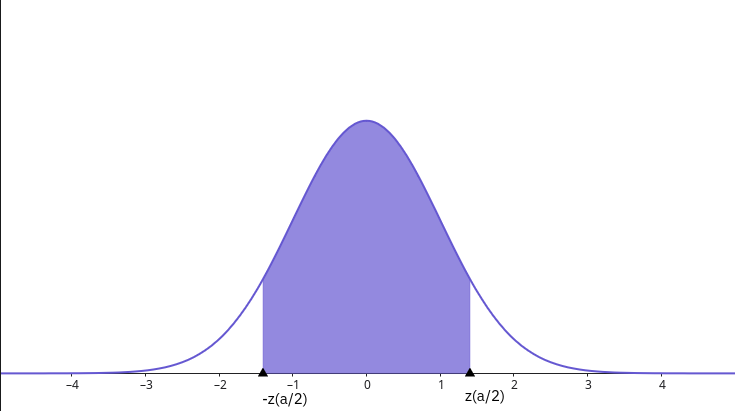

Độ tin cậy 95% $\Rightarrow 1-\alpha = 0.95 \Rightarrow \alpha = 0.05$

Khoảng tin cậy đối xứng cho kì vọng tổng thể:

$ \overline{X}-\mathcal{Z}_{\alpha/2} * \dfrac{\sigma}{\sqrt{n}} < \mu < \overline{X} + \mathcal{Z}_{\alpha/2} * \dfrac{\sigma}{\sqrt{n}}$

Trong thực tế dữ liệu, ta chưa biết phương sai tổng thể, nên thay thế bằng phương sai hiệu chỉnh mẫu $S^2$ là một ước lượng không chệch của $\sigma^2$:

$ \overline{X}-\mathcal{Z}_{\alpha/2} * \dfrac{S}{\sqrt{n}} < \mu < \overline{X} + \mathcal{Z}_{\alpha/2} * \dfrac{S}{\sqrt{n}}$

Áp dụng với mẫu dữ liệu thực tế $W_x = (x_1,x_2,...,x_{4500})$ với độ tin cậy 95% có:

$ \overline{x}-\mathcal{Z}_{0.025} * \dfrac{s}{\sqrt{n}} < \mu < \overline{x} + \mathcal{Z}_{0.025} * \dfrac{s}{\sqrt{n}}$


Tính $\overline{x}$ và $s$:

In [2]:
x_average = df_subset['Daily_Usage_Hours'].mean() #mean là hàm tính trung bình giá trị của một danh sách giá trị
s = df_subset['Daily_Usage_Hours'].std() #std là hàm tính độ lệch chuẩn của một danh sách giá trị
print(f"x_average: {x_average}, s: {s}")


x_average: 5.296, s: 2.630701156581443


Tra bảng phân phối chuẩn, có $ \mathcal{Z}_{0.025} \approx 1.96$

Khoảng tin cậy đối xứng cho kì vọng tổng thể với độ tin cậy 95%

In [3]:
n = 4500
upper = x_average + 1.96 * (s / (n ** 0.5))
lower = x_average - 1.96 * (s / (n ** 0.5))
print(f"Khoảng tin cậy đối xứng cho kì vọng tổng thể  cho Daily_Usage_Hours với độ tin cậy 95% là: ({lower}, {upper})")


Khoảng tin cậy đối xứng cho kì vọng tổng thể  cho Daily_Usage_Hours với độ tin cậy 95% là: (5.219136292235849, 5.372863707764152)


Như vậy, ta có thể kết luận thời gian sử dụng mạng xã hội trung bình hàng ngày của học sinh sinh viên nằm trong khoảng 5.2191 tiếng tới 5.3729 tiếng với độ tin cậy 95%

### 2.3. Với một biến định lượng, ước lượng phương sai tổng thể bằng khoảng tin cậy 95%.

Xét cột "Weekend_Extra_Hours"

Gọi X là biến ngẫu nhiên đại diện cho thời gian sử dụng mạng xã hội vào cuối tuần của sinh viên.

Theo như thông tin cho trước của bộ dữ liệu, X có phân phối chuẩn : $


### 2.4 Với một biến định tính có hai giá trị (nhị phân), ước lượng tỷ lệ tổng thể bằng khoảng tin cậy 95%. 

Xét cột 'Late_Night_Usage', ta gọi $X$ là biến ngẫu nhiên đại diện cho trạng thái sử dụng điện thoại vào ban đêm của sinh viên:\
$X$ = $\begin{cases} 1 & \text{Nếu sinh viên dùng điện thoại ban đêm} \\ 0 & \text{Nếu sinh viên không dùng điện thoại vào ban đêm} \end{cases}$\
Ta lấy toàn bộ cột này thành lập mẫu ngẫu nhiên $W_X=(X_1,X_2, ...,X_{4500})$\
Ta thấy biến $X \sim \mathcal{B}(p)$ với $p$ là tỷ lệ sinh viên sử dụng điện thoại ban đêm trong toàn bộ tổng thể $(0<p<1)$\
Tính toán ước lượng điểm của $p$ là tần suất mẫu $\hat{p} = \frac{y}{n}$

In [4]:
late_night_uses = df['Late_Night_Usage'].sum()
student_count = df['Late_Night_Usage'].count()
p_hat = late_night_uses / student_count
print(f"Tần suất mẫu: {p_hat:.4f}")

Tần suất mẫu: 0.5876


Kiểm tra điều kiện xấp xỉ chuẩn $\begin{cases} n\hat{p} \ge 5 \\ n(1-\hat{p}) \ge 5 \end{cases}$

In [5]:
if student_count*p_hat >= 5 and student_count*(1-p_hat) >= 5:
    print("Thỏa mãn điều kiện")
else: print("Không thỏa mãn điều kiện")

Thỏa mãn điều kiện


Như vậy, theo định lý Giới hạn trung tâm, thống kê tần suất mẫu $\widehat{P}$ có phân phối xấp xỉ chuẩn $\widehat{P} \approx \mathcal{N}\left(p, \; \frac{p(1-p)}{n}\right)$\
Đặt biến $Z = \frac{\widehat{P} - p}{\sqrt{\frac{p(1 - p)}{n}}} \Rightarrow Z \xrightarrow{d} \mathcal{N}(0, 1)$\


<div style="width: 50%;">

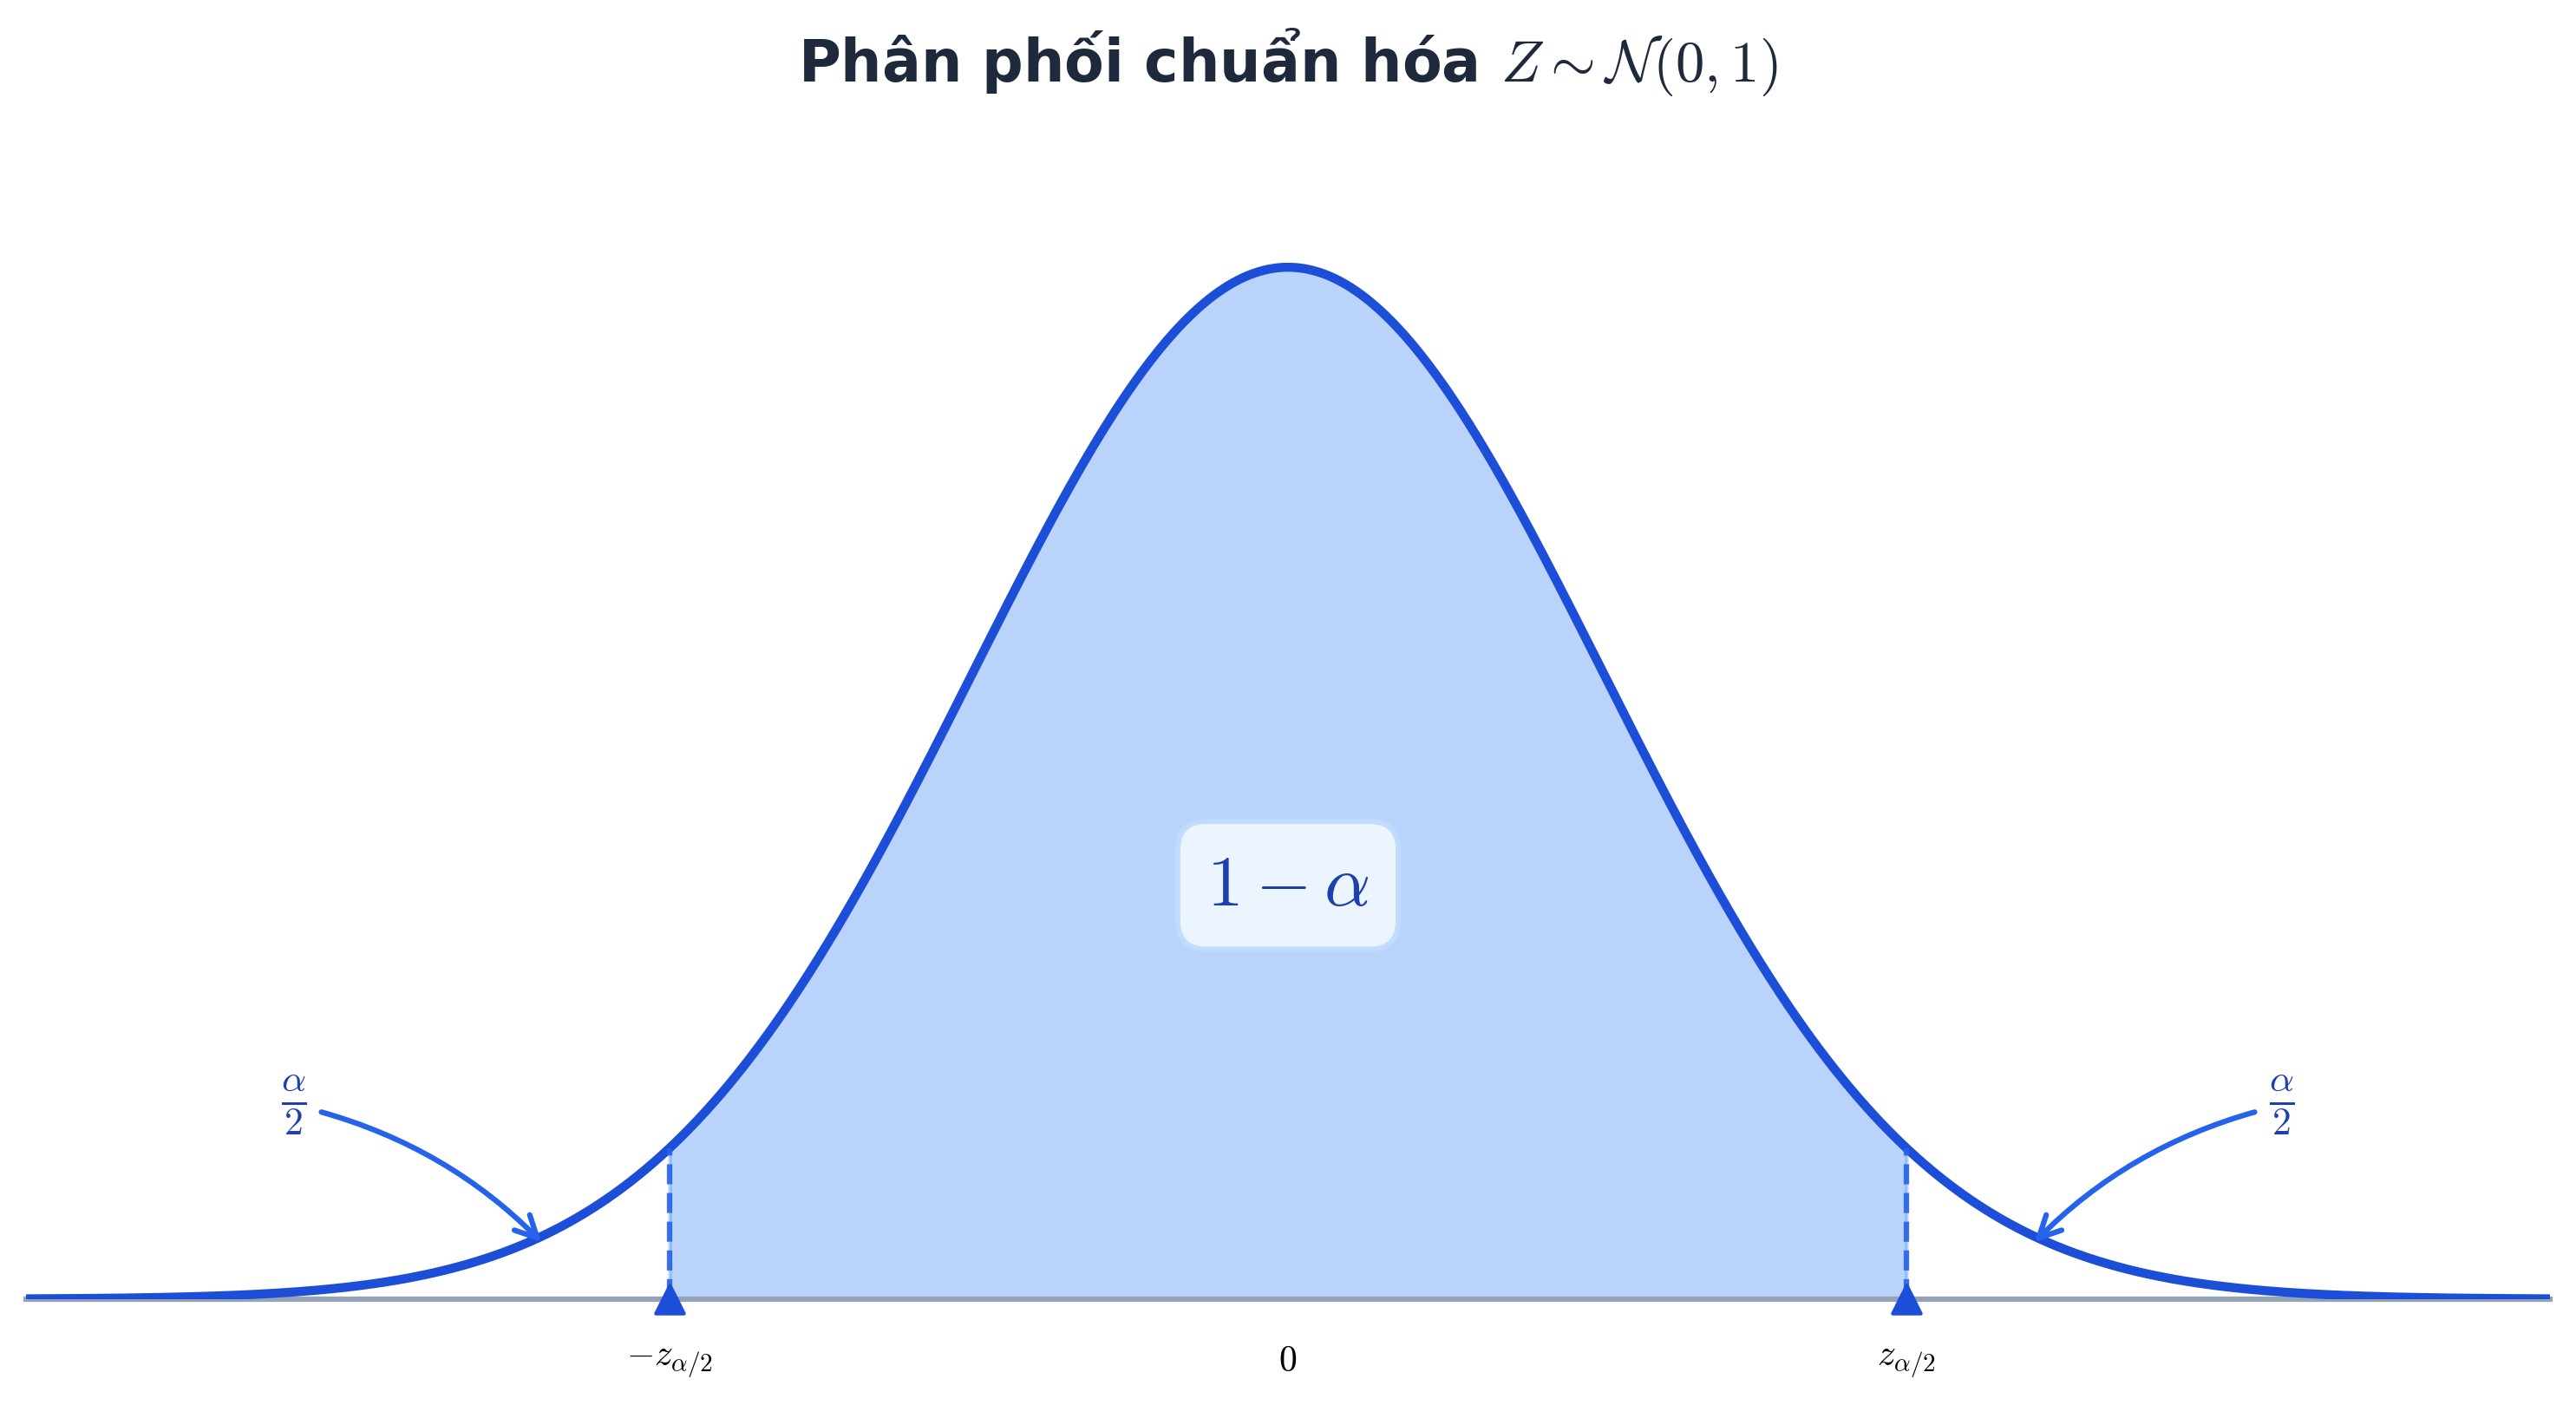

</div>


$\begin{aligned}
\text{Như vậy:}\\
& P\left(-z_{\alpha/2} < \frac{\widehat{P}-p}{\sqrt{\frac{\widehat{P}(1-\widehat{P})}{n}}} < z_{\alpha/2}\right) = 1 - \alpha \\
\iff & P\left(-z_{\alpha/2}\sqrt{\frac{\widehat{P}(1-\widehat{P})}{n}} < \widehat{P} - p < z_{\alpha/2}\sqrt{\frac{\widehat{P}(1-\widehat{P})}{n}}\right) = 1 - \alpha \\
\iff & P\left(-\widehat{P} - z_{\alpha/2}\sqrt{\frac{\widehat{P}(1-\widehat{P})}{n}} < -p < -\widehat{P} + z_{\alpha/2}\sqrt{\frac{\widehat{P}(1-\widehat{P})}{n}}\right) = 1 - \alpha \\
\iff & P\left(\widehat{P} + z_{\alpha/2}\sqrt{\frac{\widehat{P}(1-\widehat{P})}{n}} > p > \widehat{P} - z_{\alpha/2}\sqrt{\frac{\widehat{P}(1-\widehat{P})}{n}}\right) = 1 - \alpha \\
\iff & P\left(\widehat{P} - z_{\alpha/2}\sqrt{\frac{\widehat{P}(1-\widehat{P})}{n}} < p < \widehat{P} + z_{\alpha/2}\sqrt{\frac{\widehat{P}(1-\widehat{P})}{n}}\right) = 1 - \alpha \\
\iff & P\left(\widehat{P} - \varepsilon < p < \widehat{P} + \varepsilon\right) = 1 - \alpha
\end{aligned}$ \
Với $\varepsilon = \widehat{P} - z_{\alpha/2}\sqrt{\frac{\widehat{P}(1-\widehat{P})}{n}}$ \
Với độ tin cậy $(1 - \alpha = 0.95 \implies \alpha = 0.05 \implies \frac{\alpha}{2} = 0.025).$\
Tra bảng phân phối chuẩn tắc $\mathcal{N}(0, 1)$ ta có giá trị tới hạn: $[z_{\alpha/2} = z_{0.025} = 1.96]$\
Ta áp dụng vào mẫu đang có:

In [6]:
# Tính sai số biên
import math as m
z = 1.96
moe = z*m.sqrt(p_hat*(1-p_hat) / student_count)
print(f"Sai số biên: {moe}")

Sai số biên: 0.01438324943393314


In [31]:
# Tính khoảng tin cậy
ci_lower = p_hat - moe
ci_upper = p_hat + moe
print(f"Khoảng tin cậy 95% về tần suất sử dụng điện thoại ban đêm của toàn bộ sinh viên là: ({ci_lower:.4f}, {ci_upper:.4f})")

Khoảng tin cậy 95% về tần suất sử dụng điện thoại ban đêm của toàn bộ sinh viên là: (0.5653, 0.6098)


Như vậy có thể kết luận được có từ 56,53% - 60,98% sinh viên sử dụng điện thoại vào ban đêm với độ tin cậy 95%

### 2.5 Chọn hai nhóm khác nhau trong dữ liệu (dựa trên biến định tính), so sánh kỳ vọng của một biến định lượng giữa hai nhóm bằng cách xây dựng khoảng tin cậy cho hiệu kỳ vọng $µ_1 - µ_2$.

Ta khảo sát biến định lượng 'Academic_Performance_GPA' (Tức điểm GPA) của 2 nhóm học sinh theo biến định tính 'Late_Night_Usage' đã xét bên trên. Khi xét hiệu 2 kỳ vọng $\mu_1-\mu_2$ ta sẽ thấy được chênh lệch GPA trung bình giữa những sinh viên sử dụng điện thoại ban đêm và những sinh viên không dùng điện thoại ban đêm với độ tin cậy $95\%$.

Ta thực hiện tách bảng theo biến Late_Night_Usage. Bảng chia thành 2 nhóm.

In [32]:
no = df.loc[~df['Late_Night_Usage']].dropna()
yes = df.loc[df['Late_Night_Usage']].dropna()

### Ước lượng khoảng tin cậy cho hiệu hai kỳ vọng ($\mu_1 - \mu_2$)

Gọi $X_1$ là điểm GPA của nhóm sinh viên **không sử dụng thiết bị ban đêm** (`Late_Night_Usage = False`), với kỳ vọng $\mu_1$ và phương sai $\sigma_1^2$.  
Gọi $X_2$ là điểm GPA của nhóm sinh viên **có sử dụng thiết bị ban đêm** (`Late_Night_Usage = True`), với kỳ vọng $\mu_2$ và phương sai $\sigma_2^2$.

Xét cỡ mẫu của nghiên cứu rất lớn ($n \approx 4500$, trong đó $n_1, n_2 \gg 30$). Theo **Định lý Giới hạn Trung tâm (CLT)**, trung bình mẫu của hai nhóm có phân phối xấp xỉ chuẩn:

$$\overline{X}_1 \sim \mathcal{N}\left(\mu_1, \frac{\sigma_1^2}{n_1}\right), \quad \overline{X}_2 \sim \mathcal{N}\left(\mu_2, \frac{\sigma_2^2}{n_2}\right)$$

Do hai nhóm độc lập, hiệu hai trung bình mẫu $(\overline{X}_1 - \overline{X}_2)$ cũng có phân phối xấp xỉ chuẩn:

$$(\overline{X}_1 - \overline{X}_2) \sim \mathcal{N}\left(\mu_1 - \mu_2, \frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}\right)$$

Đặt biến ngẫu nhiên chuẩn hóa:

$$Z = \frac{(\overline{X}_1 - \overline{X}_2) - (\mu_1 - \mu_2)}{\sqrt{\dfrac{\sigma_1^2}{n_1} + \dfrac{\sigma_2^2}{n_2}}} \xrightarrow{d} \mathcal{N}(0, 1)$$

Do phương sai tổng thể $\sigma_1^2, \sigma_2^2$ chưa biết, với cỡ mẫu rất lớn ta thay bằng ước lượng điểm vững là các phương sai mẫu hiệu chỉnh $S_1^2$ và $S_2^2$:

$$Z \approx \frac{(\overline{X}_1 - \overline{X}_2) - (\mu_1 - \mu_2)}{\sqrt{\dfrac{S_1^2}{n_1} + \dfrac{S_2^2}{n_2}}} \sim \mathcal{N}(0, 1)$$

<div style="width: 50%;">

![image.png](normal_dis_95percent)

</div>

Như vậy, với độ tin cậy $1 - \alpha$:

$$P\left(-z_{\alpha/2} < \frac{(\overline{X}_1 - \overline{X}_2) - (\mu_1 - \mu_2)}{\sqrt{\dfrac{S_1^2}{n_1} + \dfrac{S_2^2}{n_2}}} < z_{\alpha/2}\right) = 1 - \alpha$$

$$\iff P\left(-z_{\alpha/2} \sqrt{\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}} < (\overline{X}_1 - \overline{X}_2) - (\mu_1 - \mu_2) < z_{\alpha/2} \sqrt{\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}}\right) = 1 - \alpha$$

$$\iff P\left(-(\overline{X}_1 - \overline{X}_2) - z_{\alpha/2} \sqrt{\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}} < -(\mu_1 - \mu_2) < -(\overline{X}_1 - \overline{X}_2) + z_{\alpha/2} \sqrt{\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}}\right) = 1 - \alpha$$

$$\iff P\left((\overline{X}_1 - \overline{X}_2) + z_{\alpha/2} \sqrt{\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}} > \mu_1 - \mu_2 > (\overline{X}_1 - \overline{X}_2) - z_{\alpha/2} \sqrt{\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}}\right) = 1 - \alpha$$

$$\iff P\left((\overline{X}_1 - \overline{X}_2) - z_{\alpha/2} \sqrt{\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}} < \mu_1 - \mu_2 < (\overline{X}_1 - \overline{X}_2) + z_{\alpha/2} \sqrt{\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}}\right) = 1 - \alpha$$

$$\iff P\Big((\overline{X}_1 - \overline{X}_2) - \varepsilon < \mu_1 - \mu_2 < (\overline{X}_1 - \overline{X}_2) + \varepsilon\Big) = 1 - \alpha$$

Với độ chính xác (biên sai số):

$$\varepsilon = z_{\alpha/2} \sqrt{\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}}$$

Với độ tin cậy $(1 - \alpha = 0.95 \implies \alpha = 0.05 \implies \frac{\alpha}{2} = 0.025 \implies z_{0.025} \approx 1.96)$.

Dưới đây ta sẽ thực hiện tính toán cụ thể:

Xây dựng các đại lượng cơ bản

In [28]:
import numpy as np
# Trung bình mẫu
m1 = no['Academic_Performance_GPA'].mean()
m2 = yes['Academic_Performance_GPA'].mean()
# Số lượng mẫu
n1 = len(no)
n2 = len(yes)
# Phương sai mẫu hiệu chỉnh của từng biến
x1 = no['Academic_Performance_GPA'].to_numpy()
x2 = yes['Academic_Performance_GPA'].to_numpy()

s1_sq = np.sum((x1 - m1)**2) / (n1 - 1)
s2_sq = np.sum((x2 - m2)**2) / (n2 - 1)
# Phương sai mẫu của hiệu 2 trung bình mẫu
diff = m1 - m2
se_diff = np.sqrt((s1_sq / n1) + (s2_sq / n2))
# Sai số biên
moe = 1.96*se_diff

print(f"Cỡ mẫu nhóm không dùng (n1): {n1}")
print(f"Cỡ mẫu nhóm có dùng (n2): {n2}")
print(f"Trung bình mẫu nhóm không dùng (m1): {m1:.4f}")
print(f"Trung bình mẫu nhóm có dùng (m2): {m2:.4f}")
print(f"Phương sai mẫu hiệu chỉnh biến x1 (s1^2): {s1_sq:.4f}")
print(f"Phương sai mẫu hiệu chỉnh biến x2 (s2^2): {s2_sq:.4f}")
print(f"Hiệu hai trung bình mẫu (diff): {diff:.4f}")
print(f"Sai số biên (moe): {moe:.4f}")

Cỡ mẫu nhóm không dùng (n1): 1809
Cỡ mẫu nhóm có dùng (n2): 2560
Trung bình mẫu nhóm không dùng (m1): 3.5488
Trung bình mẫu nhóm có dùng (m2): 3.3455
Phương sai mẫu hiệu chỉnh biến x1 (s1^2): 0.1194
Phương sai mẫu hiệu chỉnh biến x2 (s2^2): 0.1621
Hiệu hai trung bình mẫu (diff): 0.2032
Sai số biên (moe): 0.0223


Từ các đại lượng này, ta tính được ra khoảng tin cậy 95%

In [30]:
ci_lower = diff - moe
ci_upper = diff + moe
print(f"Khoảng tin cậy 95% về sự chênh lệch GPA giữa các sinh viên dùng điện thoại ban đêm và các sinh viên không dùng là: ({ci_lower:.4f}, {ci_upper:.4f})")

Khoảng tin cậy 95% về sự chênh lệch GPA giữa các sinh viên dùng điện thoại ban đêm và các sinh viên không dùng là: (0.1810, 0.2255)
